In [5]:
import pandas as pd
import numpy as np

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
data = pd.read_csv("emails.csv")

print(data.head())

print(data.shape)

print(data.info())

  label                                               text
0   ham  Hi Lavanya can we meet tomorrow for the projec...
1  spam  Congratulations! You have won a FREE iPhone. C...
2   ham              Please send me today's meeting notes.
3  spam          Limited time offer! Buy one get one free.
4   ham  Your assignment submission has been received s...
(30, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   30 non-null     object
 1   text    30 non-null     object
dtypes: object(2)
memory usage: 608.0+ bytes
None


In [8]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = ''.join([char for char in text if char not in string.punctuation])

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data["clean_text"] = data["text"].apply(preprocess)

print(data.head())

  label                                               text  \
0   ham  Hi Lavanya can we meet tomorrow for the projec...   
1  spam  Congratulations! You have won a FREE iPhone. C...   
2   ham              Please send me today's meeting notes.   
3  spam          Limited time offer! Buy one get one free.   
4   ham  Your assignment submission has been received s...   

                                    clean_text  
0  hi lavanya meet tomorrow project discussion  
1            congratulations free iphone click  
2             please send todays meeting notes  
3      limited time offer buy one get one free  
4  assignment submission received successfully  


In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data["clean_text"])

y = data["label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [13]:
y_pred = model.predict(X_test)

print(y_pred)

['ham' 'ham' 'ham' 'spam' 'ham' 'ham']


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.3333333333333333


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.20      1.00      0.33         1
        spam       1.00      0.20      0.33         5

    accuracy                           0.33         6
   macro avg       0.60      0.60      0.33         6
weighted avg       0.87      0.33      0.33         6



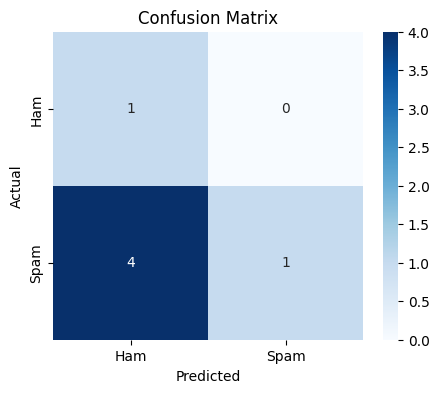

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

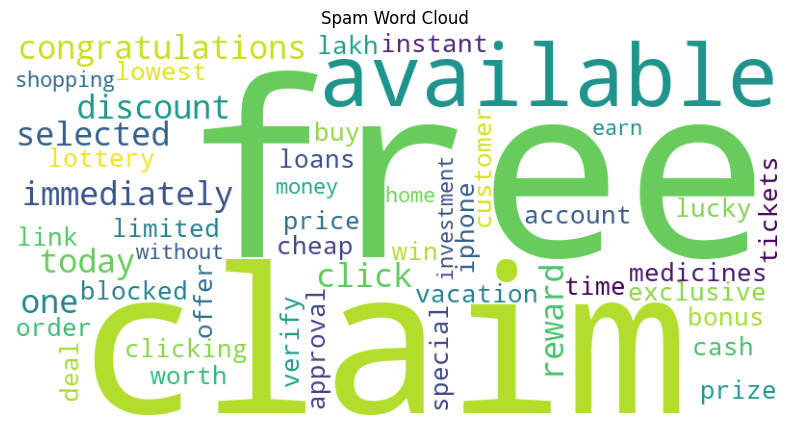

In [17]:
spam_words = " ".join(data[data.label=="spam"]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

In [21]:
email = input("Enter Email Text : ")

email = preprocess(email)

email = vectorizer.transform([email])

prediction = model.predict(email)

print()

print("Prediction =", prediction[0])


Prediction = spam


Spam Emails : 15
Non-Spam Emails : 15


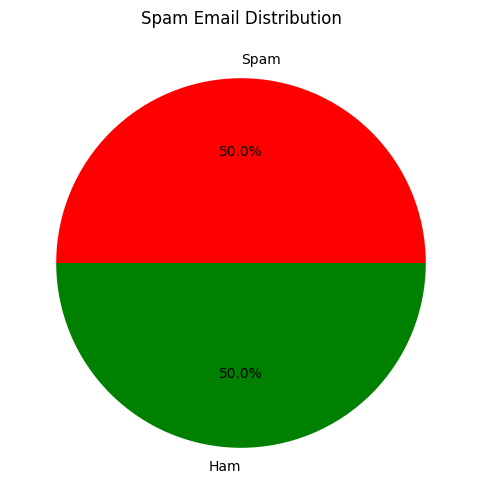

In [22]:
spam = len(data[data.label=="spam"])

ham = len(data[data.label=="ham"])

print("Spam Emails :", spam)

print("Non-Spam Emails :", ham)

plt.figure(figsize=(6,6))

plt.pie(
    [spam,ham],
    labels=["Spam","Ham"],
    autopct="%1.1f%%",
    colors=["red","green"]
)

plt.title("Spam Email Distribution")

plt.show()